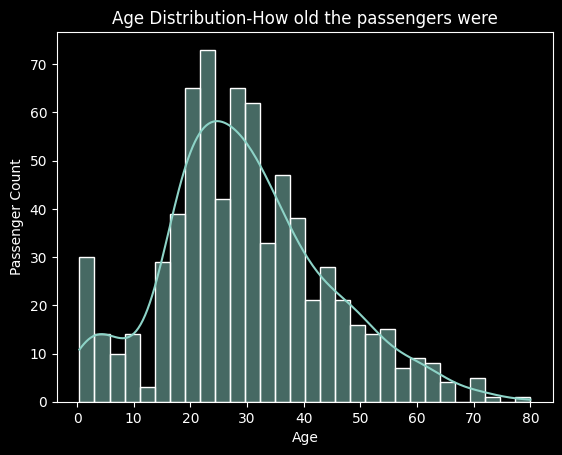

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")
#df.hist(column="Age", grid=False, bins=80)
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.title("Age Distribution-How old the passengers were")
plt.show()


In [47]:
df.head(3)
df["Total members"] = df["SibSp"] + df["Parch"] + 1
df.head(3)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Boarded Port,Total members
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Southampton,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cherbourg,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Southampton,1


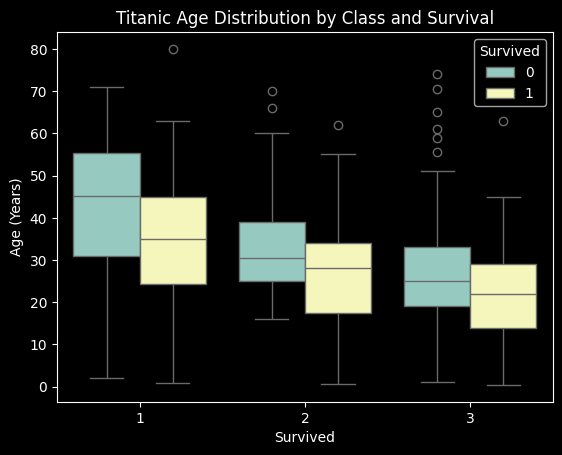

In [37]:
sns.boxplot(data=df, x="Pclass", y="Age", hue="Survived")

plt.title("Titanic Age Distribution by Class and Survival")
plt.xlabel("Survived")
plt.ylabel("Age (Years)")
plt.show()

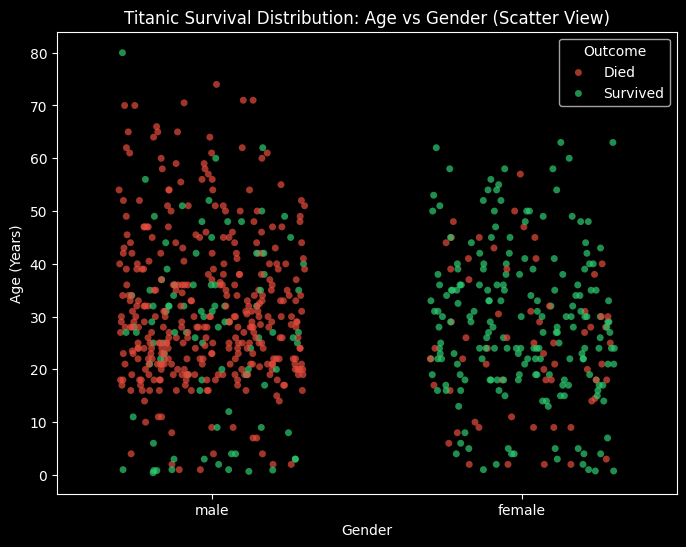

In [39]:
#sns.scatterplot(data=df, x="Sex", y="Age", hue="Survived")
#plt.title("Titanic: Age vs. Gender by Survival Status")
#plt.xlabel("Gender")
#plt.ylabel("Age")
#plt.show()

plt.figure(figsize=(8, 6))

# 1. Use stripplot to create a scattered dot plot with horizontal spread (jitter)
sns.stripplot(
    data=df,
    x="Sex",
    y="Age",
    hue="Survived",
    jitter=0.3,                 # Spreads the dots out horizontally so you can see them
    alpha=0.7,                  # Makes dots semi-transparent to see overlapping points
    palette={0: "#e74c3c", 1: "#2ecc71"}, # Red for Died, Green for Survived
    size=5                      # Adjusts dot size to reduce crowding
)

# 2. Format labels and titles
plt.title("Titanic Survival Distribution: Age vs Gender (Scatter View)")
plt.xlabel("Gender")
plt.ylabel("Age (Years)")

# Fix the legend labels from 0/1 to Died/Survived
plt.legend(title="Outcome", labels=["Died", "Survived"])

plt.show()

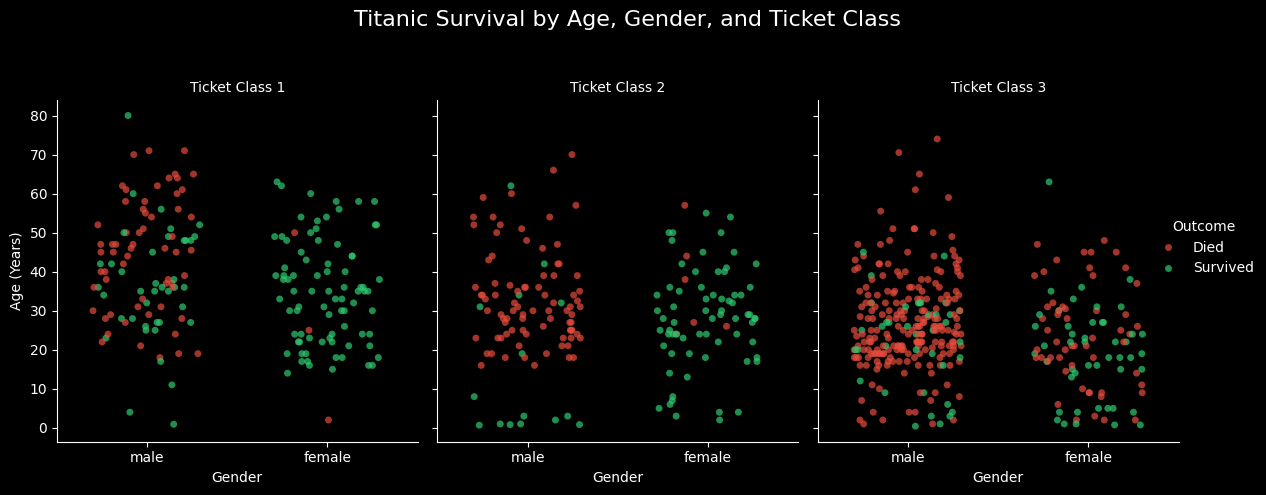

In [40]:
## how did age, ticket class and gender together influence survival
g = sns.catplot(data=df, x="Sex", y="Age", hue="Survived", col="Pclass", kind="strip",
                jitter=0.3,                 # Spreads the dots out horizontally so you can see them
                alpha=0.7,                  # Makes dots semi-transparent to see overlapping points
                palette={0: "#e74c3c", 1: "#2ecc71"},
                height=5,
                aspect=0.8) # Red for Died, Green for Survived)
# Clean up titles and axis labels across the subplots
g.set_titles("Ticket Class {col_name}")
g.set_axis_labels("Gender", "Age (Years)")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Titanic Survival by Age, Gender, and Ticket Class", fontsize=16)

# Fix the legend labels
g._legend.set_title("Outcome")
new_labels = ["Died", "Survived"]
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

plt.show()

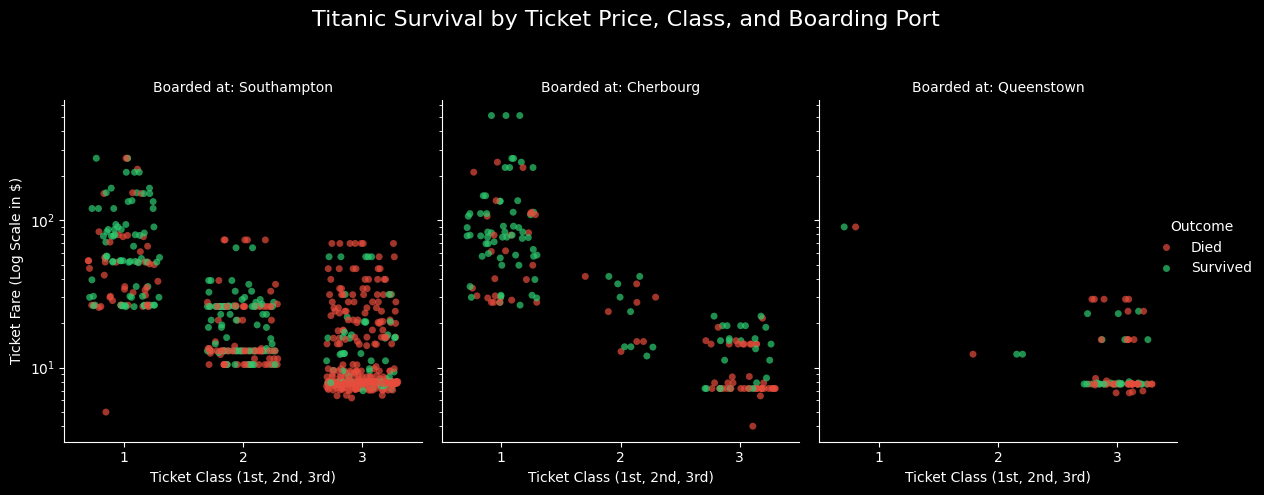

In [45]:
## how did ticket price, class and where passenger boarded collectively influence survival
df = df.dropna(subset=['Embarked'])
port_map = {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}
df["Boarded Port"] = df["Embarked"].map(port_map)
g = sns.catplot(data=df, x="Pclass", y="Fare", hue="Survived", col="Boarded Port", kind="strip",
                jitter=0.3,                 # Spreads the dots out horizontally so you can see them
                alpha=0.7,                  # Makes dots semi-transparent to see overlapping points
                palette={0: "#e74c3c", 1: "#2ecc71"},
                height=5,
                aspect=0.8) # Red for Died, Green for Survived)
# Clean up titles and axis labels across the subplots
g.set_titles("Ticket Class {col_name}")
g.set_axis_labels("Embarked", "Fare")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Titanic Survival by Age, Gender, and Ticket Class", fontsize=16)

# Apply a log scale to the Y-axis because Fare ranges from $0 to $512
for ax in g.axes.flat:
    ax.set_yscale("log")

# Format titles and labels
g.set_titles("Boarded at: {col_name}")
g.set_axis_labels("Ticket Class (1st, 2nd, 3rd)", "Ticket Fare (Log Scale in $)")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    "Titanic Survival by Ticket Price, Class, and Boarding Port", fontsize=16
)

# Fix the legend labels
g._legend.set_title("Outcome")
new_labels = ["Died", "Survived"]
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)

plt.show()

## PCA on the Titanic Dataset

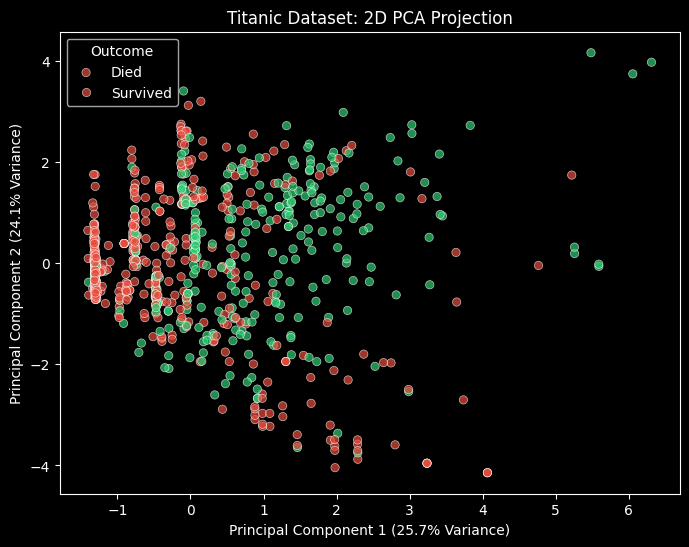

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv("Titanic-Dataset.csv")

# 2. Preprocessing (Fill missing values & convert text to numbers)
# Fill missing ages with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())
# Fill missing Embarked with the most common port
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Map text categories to numbers
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Select features for PCA (drop identifying columns and the target 'Survived')
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[features]
y = df["Survived"]

# 3. Scale the Data (Mandatory for PCA!)
# PCA is highly sensitive to variances; Fare ($0-$512) would dominate Age ($0-$80) without scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply PCA (Reduce to 2 components for easy plotting)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame with the PCA results
df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca["Survived"] = y

# 5. Plot the PCA Results
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Survived",
    alpha=0.7,
    palette={0: "#e74c3c", 1: "#2ecc71"},
)

plt.title("Titanic Dataset: 2D PCA Projection")
plt.xlabel(
    f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)"
)
plt.ylabel(
    f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)"
)
plt.legend(title="Outcome", labels=["Died", "Survived"])
plt.show()


# Check Collinearity

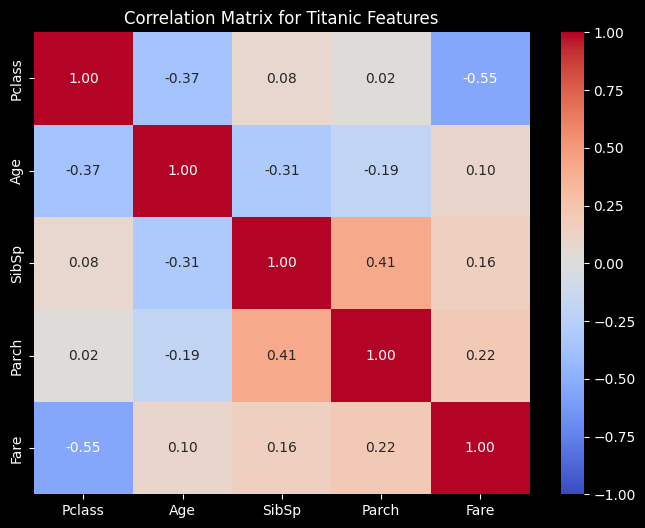

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

# 1. Select your numerical features
features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df[features].corr()

# 2. Plot as a colored heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix for Titanic Features")
plt.show()
